### Fig 3

Warning message:
“Graphs cannot be vertically aligned unless the axis parameter is set. Placing graphs unaligned.”


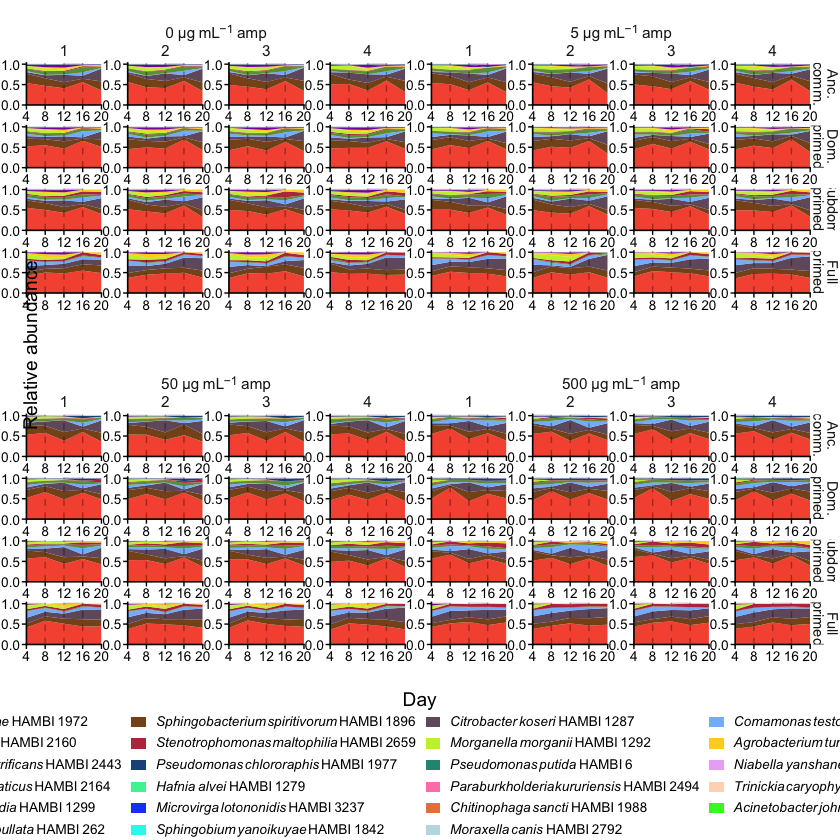

In [1]:
if (exists("plot", inherits = FALSE)) {
  rm(plot)
}

suppressPackageStartupMessages({
  library(tidyverse)
  library(ggtext)
  library(ggh4x)
  library(ggnewscale)
  library(scales)
  library(cowplot)
})

if (requireNamespace("conflicted", quietly = TRUE)) {
  conflicted::conflict_prefer("select", "dplyr", quiet = TRUE)
  conflicted::conflict_prefer("filter", "dplyr", quiet = TRUE)
  conflicted::conflict_prefer("lag", "dplyr", quiet = TRUE)
  conflicted::conflict_prefer("rename", "dplyr", quiet = TRUE)
}

data_dir <- "../data"
fig_dir  <- "../figs"

dir.create(
  fig_dir,
  recursive = TRUE,
  showWarnings = FALSE
)

pdf_device <- if (capabilities("cairo")) {
  grDevices::cairo_pdf
} else {
  "pdf"
}

# -------------------------------------------------------------------------
# Treatment colours
# -------------------------------------------------------------------------

ab_cols <- c(
  "0"   = "#BBBBBC",
  "5"   = "#D3C2E8",
  "50"  = "#AD8CB9",
  "500" = "#6D2682"
)

# -------------------------------------------------------------------------
# Species colours
# -------------------------------------------------------------------------

species_colors <- c(
  "HAMBI_1988" = "#EA7F40",
  "HAMBI_3031" = "#EAB0F6",
  "HAMBI_1896" = "#834F16",
  "HAMBI_3237" = "#1649F7",
  "HAMBI_0105" = "#FDD21C",
  "HAMBI_2443" = "#8200AA",
  "HAMBI_1842" = "#0DF8EB",
  "HAMBI_0262" = "#FD0D7A",
  "HAMBI_2160" = "#6A9940",
  "HAMBI_0403" = "#82BAFE",
  "HAMBI_2164" = "#FA2AD9",
  "HAMBI_2494" = "#FD83B5",
  "HAMBI_2159" = "#FED8BE",
  "HAMBI_0097" = "#2AF622",
  "HAMBI_2792" = "#BEDDE4",
  "HAMBI_1292" = "#C4EF35",
  "HAMBI_1279" = "#42F19F",
  "HAMBI_1299" = "#DC16FC",
  "HAMBI_1287" = "#70566A",
  "HAMBI_1972" = "#F6533B",
  "HAMBI_1977" = "#164F85",
  "HAMBI_0006" = "#22917A",
  "HAMBI_2659" = "#BA3249"
)

species_labels_html <- c(
  "HAMBI_0006" = "<i>Pseudomonas putida</i> HAMBI 6",
  "HAMBI_0097" = "<i>Acinetobacter johnsonii</i> HAMBI 97",
  "HAMBI_0105" = "<i>Agrobacterium tumefaciens</i> HAMBI 105",
  "HAMBI_0262" = "<i>Brevundimonas bullata</i> HAMBI 262",
  "HAMBI_0403" = "<i>Comamonas testosteroni</i> HAMBI 403",
  "HAMBI_1279" = "<i>Hafnia alvei</i> HAMBI 1279",
  "HAMBI_1287" = "<i>Citrobacter koseri</i> HAMBI 1287",
  "HAMBI_1292" = "<i>Morganella morganii</i> HAMBI 1292",
  "HAMBI_1299" = "<i>Kluyvera intermedia</i> HAMBI 1299",
  "HAMBI_1842" = "<i>Sphingobium yanoikuyae</i> HAMBI 1842",
  "HAMBI_1896" = "<i>Sphingobacterium spiritivorum</i> HAMBI 1896",
  "HAMBI_1972" = "<i>Aeromonas caviae</i> HAMBI 1972",
  "HAMBI_1977" = "<i>Pseudomonas chlororaphis</i> HAMBI 1977",
  "HAMBI_1988" = "<i>Chitinophaga sancti</i> HAMBI 1988",
  "HAMBI_2159" = "<i>Trinickia caryophylli</i> HAMBI 2159",
  "HAMBI_2160" = "<i>Bordetella avium</i> HAMBI 2160",
  "HAMBI_2164" = "<i>Cupriavidus oxalaticus</i> HAMBI 2164",
  "HAMBI_2443" = "<i>Paracoccus denitrificans</i> HAMBI 2443",
  "HAMBI_2494" = "<i>Paraburkholderia kururiensis</i> HAMBI 2494",
  "HAMBI_2659" = "<i>Stenotrophomonas maltophilia</i> HAMBI 2659",
  "HAMBI_2792" = "<i>Moraxella canis</i> HAMBI 2792",
  "HAMBI_3031" = "<i>Niabella yanshanensis</i> HAMBI 3031",
  "HAMBI_3237" = "<i>Microvirga lotononidis</i> HAMBI 3237"
)

names(species_colors) <- gsub(
  "-",
  "_",
  names(species_colors)
)

names(species_labels_html) <- gsub(
  "-",
  "_",
  names(species_labels_html)
)

# -------------------------------------------------------------------------
# Figure theme
# -------------------------------------------------------------------------

comp_theme <- function() {
  theme_classic(base_size = 11) +
    theme(
      panel.background = element_rect(
        fill = "white",
        colour = NA
      ),

      plot.background = element_rect(
        fill = "white",
        colour = NA
      ),

      axis.line = element_line(
        colour = "black",
        linewidth = 0.45
      ),

      axis.ticks = element_line(
        colour = "black",
        linewidth = 0.4
      ),

      # Keep tick labels large relative to the panels
      axis.text.x = element_text(
        size = 8.2,
        face = "plain",
        colour = "black",
        margin = margin(t = 1)
      ),

      axis.text.y = element_text(
        size = 8.2,
        face = "plain",
        colour = "black",
        margin = margin(r = 1)
      ),

      # Shared titles are added during final assembly
      axis.title = element_blank(),

      strip.background = element_rect(
        fill = "white",
        colour = NA
      ),

      # Treatment headings and replicate numbers
      strip.text.x = ggtext::element_markdown(
        face = "plain",
        size = 9.2,
        lineheight = 0.95,

        # Keep each heading close to the panels below it
        margin = margin(
          t = 0,
          r = 0,
          b = 2,
          l = 0,
          unit = "pt"
        )
      ),

      # Short, readable row-facet labels
      strip.text.y = ggtext::element_markdown(
        face = "plain",
        size = 8.8,
        lineheight = 0.90,
        margin = margin(
          t = 0,
          r = 0,
          b = 0,
          l = 0,
          unit = "pt"
        )
      ),

      strip.text.y.left = ggtext::element_markdown(
        face = "plain",
        size = 8.8,
        lineheight = 0.90,
        margin = margin(0, 0, 0, 0)
      ),

      strip.text.y.right = ggtext::element_markdown(
        face = "plain",
        size = 8.8,
        lineheight = 0.90,
        margin = margin(0, 0, 0, 0)
      ),

      legend.title = element_blank(),

      legend.text = ggtext::element_markdown(
        size = 8.2,
        face = "plain",
        lineheight = 0.96
      ),

      legend.key.height = grid::unit(6, "pt"),
      legend.key.width  = grid::unit(10, "pt"),

      legend.spacing.x = grid::unit(4, "pt"),
      legend.spacing.y = grid::unit(0, "pt"),

      legend.margin = margin(0, 0, 0, 0),
      legend.box.margin = margin(0, 0, 0, 0),

      legend.background = element_rect(
        fill = "white",
        colour = NA
      ),

      legend.box = "horizontal",
      legend.justification = "center",

      panel.spacing.x = grid::unit(0.06, "lines"),
      panel.spacing.y = grid::unit(0.08, "lines"),

      # Shorter panels substantially reduce total figure height
      aspect.ratio = 0.56,

      plot.margin = margin(
        t = 1,
        r = 1,
        b = 1,
        l = 1,
        unit = "pt"
      )
    )
}

# -------------------------------------------------------------------------
# Helper
# -------------------------------------------------------------------------

fix_names <- function(x) {
  nms <- names(x)

  bad <- is.na(nms) | nms == ""

  if (any(bad)) {
    nms[bad] <- paste0(
      "X",
      seq_len(sum(bad))
    )
  }

  names(x) <- make.unique(nms)

  x
}

# -------------------------------------------------------------------------
# Load data
# -------------------------------------------------------------------------

shade_alpha_comp <- 0.18

species_raw <- fix_names(
  read.delim(
    file.path(
      data_dir,
      "species_abundance.txt"
    ),
    check.names = FALSE,
    stringsAsFactors = FALSE
  )
)

species <- species_raw %>%
  mutate(
    Day = case_when(
      grepl("d4", sample)  ~ 4,
      grepl("d8", sample)  ~ 8,
      grepl("d12", sample) ~ 12,
      grepl("d16", sample) ~ 16,
      grepl("d20", sample) ~ 20,
      TRUE                 ~ NA_real_
    ),

    Evo_orig = case_when(
      grepl("^a_", sample) ~ "All ancestral",
      grepl("^d_", sample) ~ "Evolved 1972",
      grepl("^e_", sample) ~ "Evolved 1977",
      grepl("^f_", sample) ~ "All evolved",
      TRUE                 ~ NA_character_
    ),

    Replicate = case_when(
      grepl("_1_", sample) ~ 1L,
      grepl("_2_", sample) ~ 2L,
      grepl("_3_", sample) ~ 3L,
      grepl("_4_", sample) ~ 4L,
      TRUE                 ~ NA_integer_
    ),

    AB = case_when(
      grepl("_t1_", sample) ~ 5L,
      grepl("_t2_", sample) ~ 50L,
      grepl("_t3_", sample) ~ 500L,
      grepl("_t4_", sample) ~ 0L,
      TRUE                  ~ NA_integer_
    )
  ) %>%

  filter(
    !is.na(Day),
    !is.na(Evo_orig),
    !is.na(AB),
    !is.na(Replicate)
  ) %>%

  mutate(
    # The original biological order is retained:
    # ancestral, dominant primed, subdominant primed, full primed.
    Evo_html = factor(
      Evo_orig,
      levels = c(
        "All ancestral",
        "Evolved 1972",
        "Evolved 1977",
        "All evolved"
      ),
      labels = c(
        "Anc.<br>comm.",
        "Dom.<br>primed",
        "Subdom.<br>primed",
        "Full<br>primed"
      )
    ),

    AB_fac = factor(
      AB,
      levels = c(
        0,
        5,
        50,
        500
      ),
      labels = c(
        "No pre-pulse",
        "Low pre-pulse",
        "Intermediate pre-pulse",
        "High pre-pulse"
      )
    ),

    Replicate = factor(
      Replicate,
      levels = c(
        1,
        2,
        3,
        4
      )
    ),

    strainID = gsub(
      "-",
      "_",
      strainID
    )
  )

all_days <- c(
  4,
  8,
  12,
  16,
  20
)

# -------------------------------------------------------------------------
# Calculate relative abundance
# -------------------------------------------------------------------------

comp_panel <- species %>%
  group_by(
    Evo_html,
    Evo_orig,
    AB,
    AB_fac,
    Replicate,
    Day,
    strainID
  ) %>%

  summarise(
    v = sum(
      f_correct,
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%

  group_by(
    Evo_html,
    Evo_orig,
    AB,
    AB_fac,
    Replicate,
    strainID
  ) %>%

  tidyr::complete(
    Day = all_days,
    fill = list(v = 0)
  ) %>%

  arrange(
    Day,
    .by_group = TRUE
  ) %>%

  ungroup() %>%

  group_by(
    Evo_html,
    Evo_orig,
    AB,
    AB_fac,
    Replicate,
    Day
  ) %>%

  mutate(
    frac = v / pmax(
      sum(v),
      1e-12
    )
  ) %>%

  ungroup()

# -------------------------------------------------------------------------
# Order species from greatest to least total relative abundance
#
# Missing combinations implicitly contribute zero, so the total across all
# observed panels and days is an appropriate overall abundance measure.
# -------------------------------------------------------------------------

species_abundance_order <- comp_panel %>%
  group_by(
    strainID
  ) %>%

  summarise(
    total_relative_abundance = sum(
      frac,
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%

  arrange(
    desc(total_relative_abundance),
    strainID
  )

species_order <- species_abundance_order %>%
  pull(
    strainID
  )

# Add colours for any species not in the predefined palette
missing_cols <- setdiff(
  species_order,
  names(species_colors)
)

if (length(missing_cols) > 0) {
  species_colors <- c(
    species_colors,

    setNames(
      scales::hue_pal()(
        length(missing_cols)
      ),
      missing_cols
    )
  )
}

species_values <- setNames(
  unname(
    species_colors[
      species_order
    ]
  ),
  species_order
)

legend_labs <- species_labels_html[
  species_order
]

legend_labs[
  is.na(legend_labs)
] <- species_order[
  is.na(legend_labs)
]

# Factor order controls the stack and legend order
comp_panel <- comp_panel %>%
  mutate(
    strainID = factor(
      strainID,
      levels = species_order
    )
  )

# -------------------------------------------------------------------------
# Treatment shading
# -------------------------------------------------------------------------

shading_meta_comp <- comp_panel %>%
  distinct(
    Evo_html,
    AB,
    AB_fac,
    Replicate
  )

phase_rects_comp <- shading_meta_comp %>%
  tidyr::crossing(
    phase = c(
      "pre",
      "main"
    )
  ) %>%

  mutate(
    xmin = ifelse(
      phase == "pre",
      4,
      12
    ),

    xmax = ifelse(
      phase == "pre",
      8,
      16
    ),

    ymin = 0,
    ymax = 1.03,

    pre_col = unname(
      ab_cols[
        as.character(AB)
      ]
    ),

    base_col = ifelse(
      phase == "pre",
      pre_col,
      unname(ab_cols["500"])
    ),

    fill = scales::alpha(
      base_col,
      shade_alpha_comp
    )
  )

phase_bounds_comp <- tibble(
  x = c(
    4,
    8,
    12,
    16
  ),
  y = 0,
  yend = 1.03
)

ab_strip_labels <- c(
  "No pre-pulse" =
    "0 µg mL<sup>−1</sup> amp",

  "Low pre-pulse" =
    "5 µg mL<sup>−1</sup> amp",

  "Intermediate pre-pulse" =
    "50 µg mL<sup>−1</sup> amp",

  "High pre-pulse" =
    "500 µg mL<sup>−1</sup> amp"
)

# -------------------------------------------------------------------------
# Function for one two-treatment block
# -------------------------------------------------------------------------

make_comp_block <- function(
    ab_values,
    show_legend = FALSE
) {

  comp_block <- comp_panel %>%
    filter(
      AB %in% ab_values
    )

  rect_block <- phase_rects_comp %>%
    filter(
      AB %in% ab_values
    )

  ggplot() +

    geom_rect(
      data = rect_block,
      aes(
        xmin = xmin,
        xmax = xmax,
        ymin = ymin,
        ymax = ymax,
        fill = fill
      ),
      inherit.aes = FALSE,
      colour = NA
    ) +

    scale_fill_identity(
      guide = "none"
    ) +

    ggnewscale::new_scale_fill() +

    geom_area(
      data = comp_block,
      aes(
        x = Day,
        y = frac,
        fill = strainID,
        group = interaction(
          Evo_html,
          AB,
          Replicate,
          strainID
        )
      ),

      # Most abundant species is the first factor level and is placed
      # at the bottom of the stack.
      position = position_stack(
        reverse = TRUE
      ),

      colour = NA,
      alpha = 0.98
    ) +

    scale_fill_manual(
      values = species_values,
      breaks = species_order,
      limits = species_order,
      labels = legend_labs,
      name = NULL,
      drop = FALSE,

      guide = guide_legend(
        ncol = 4,
        byrow = TRUE,

        override.aes = list(
          colour = NA
        )
      )
    ) +

    geom_segment(
      data = phase_bounds_comp,
      aes(
        x = x,
        xend = x,
        y = y,
        yend = yend
      ),
      inherit.aes = FALSE,
      linetype = "dashed",
      linewidth = 0.4,
      colour = scales::alpha(
        "black",
        0.35
      )
    ) +

    ggh4x::facet_nested(
      rows = vars(
        Evo_html
      ),

      cols = vars(
        AB_fac,
        Replicate
      ),

      axes = "all",
      remove_labels = "none",

      labeller = labeller(
        AB_fac = as_labeller(
          ab_strip_labels
        )
      )
    ) +

    scale_x_continuous(
      breaks = c(
        4,
        8,
        12,
        16,
        20
      ),

      labels = c(
        "4",
        "8",
        "12",
        "16",
        "20"
      ),

      limits = c(
        4,
        20
      ),

      expand = expansion(
        mult = c(
          0,
          0
        )
      )
    ) +

    scale_y_continuous(
      breaks = c(
        0,
        0.5,
        1
      ),

      labels = c(
        "0.0",
        "0.5",
        "1.0"
      ),

      limits = c(
        0,
        1.03
      ),

      expand = expansion(
        mult = c(
          0,
          0
        )
      )
    ) +

    labs(
      x = NULL,
      y = NULL,
      fill = NULL
    ) +

    comp_theme() +

    theme(
      legend.position = if (show_legend) {
        "bottom"
      } else {
        "none"
      }
    )
}

# -------------------------------------------------------------------------
# Construct treatment blocks
# -------------------------------------------------------------------------

p_comp_top <- make_comp_block(
  ab_values = c(
    0,
    5
  ),
  show_legend = FALSE
) +

  theme(
    plot.margin = margin(
      t = 0,
      r = 1,
      b = 0,
      l = 1,
      unit = "pt"
    )
  )

p_comp_bottom <- make_comp_block(
  ab_values = c(
    50,
    500
  ),
  show_legend = FALSE
) +

  theme(
    # No negative top margin: the separation is inserted above this plot.
    # The strip margin keeps headings close to these panels.
    plot.margin = margin(
      t = 0,
      r = 1,
      b = 0,
      l = 1,
      unit = "pt"
    )
  )

# -------------------------------------------------------------------------
# Shared legend
# -------------------------------------------------------------------------

legend_source <- make_comp_block(
  ab_values = c(
    0,
    5
  ),
  show_legend = TRUE
) +

  guides(
    fill = guide_legend(
      ncol = 4,
      byrow = TRUE,

      override.aes = list(
        colour = NA
      )
    )
  ) +

  theme(
    legend.position = "bottom",
    legend.box = "horizontal",
    legend.justification = "center",
    legend.margin = margin(0, 0, 0, 0),
    legend.box.margin = margin(0, 0, 0, 0),
    plot.margin = margin(0, 0, 0, 0)
  )

legend_comp <- cowplot::get_legend(
  legend_source
)

# -------------------------------------------------------------------------
# Assemble the two treatment blocks
# -------------------------------------------------------------------------

# The blank spacer creates separation ABOVE the second block.
# It does not separate the second block's titles from its own panels.
block_spacer <- cowplot::ggdraw()

comp_grid <- cowplot::plot_grid(
  p_comp_top,
  block_spacer,
  p_comp_bottom,
  ncol = 1,
  align = "v",
  axis = "lr",

  rel_heights = c(
    1,
    0.045,
    1
  )
)

# Shared Day title directly beneath the data grid
x_title_grob <- cowplot::ggdraw() +
  cowplot::draw_label(
    "Day",
    x = 0.5,
    y = 0.55,
    size = 11.5,
    fontface = "plain",
    hjust = 0.5,
    vjust = 0.5
  )

grid_with_x_title <- cowplot::plot_grid(
  comp_grid,
  x_title_grob,
  ncol = 1,
  align = "v",

  rel_heights = c(
    1,
    0.035
  )
)

# Shared legend immediately below the Day title
comp_core <- cowplot::plot_grid(
  grid_with_x_title,
  legend_comp,
  ncol = 1,
  align = "v",

  rel_heights = c(
    1,
    0.18
  )
)

# -------------------------------------------------------------------------
# Add shared y-axis title in the plot's existing left margin
# -------------------------------------------------------------------------

p_comp <- cowplot::ggdraw() +

  # Use the full canvas for the figure; no separate left title column
  cowplot::draw_plot(
    comp_core,
    x = 0,
    y = 0,
    width = 1,
    height = 1
  ) +

  # This is substantially closer to the leftmost graph than previously
  cowplot::draw_label(
    "Relative abundance",
    x = 0.036,
    y = 0.59,
    angle = 90,
    size = 11.5,
    fontface = "plain",
    hjust = 0.5,
    vjust = 0.5
  )

# -------------------------------------------------------------------------
# Display and save
# -------------------------------------------------------------------------

print(p_comp)

ggsave(
  filename = file.path(
    fig_dir,
    "Fig3.pdf"
  ),
  plot = p_comp,
  width = 12.5,
  height = 8.4,
  units = "in",
  device = pdf_device
)

In [2]:
## ------------------------------------------------------------------
## Increased power analysis: all valid evolutionary backgrounds
## Test effect of pre-pulse while controlling for Evo_orig
## NOTE: for Pseudomonas chlororaphis, exclude backgrounds where it was
## pre-exposed and went extinct: "Evolved 1977" and "All evolved"
## ------------------------------------------------------------------

degrader_ids <- c("HAMBI_1972", "HAMBI_1977", "HAMBI_0403")

degrader_names <- c(
  "HAMBI_1972" = "Aeromonas caviae",
  "HAMBI_1977" = "Pseudomonas chlororaphis",
  "HAMBI_0403" = "Comamonas testosteroni"
)

degrader_order <- c(
  "Aeromonas caviae",
  "Pseudomonas chlororaphis",
  "Comamonas testosteroni"
)

valid_evo_by_species <- list(
  "Aeromonas caviae"         = c("All ancestral", "Evolved 1972", "Evolved 1977", "All evolved"),
  "Pseudomonas chlororaphis" = c("All ancestral", "Evolved 1972"),
  "Comamonas testosteroni"   = c("All ancestral", "Evolved 1972", "Evolved 1977", "All evolved")
)

format_p <- function(p) {
  if (is.na(p)) return(NA_character_)
  if (p < 0.001) return("< 0.001")
  if (p < 0.01)  return("< 0.01")
  sprintf("= %.3f", signif(p, 3))
}

keep_valid_backgrounds <- function(df) {
  df %>%
    rowwise() %>%
    mutate(
      keep_row = Evo_orig %in% valid_evo_by_species[[as.character(degrader)]]
    ) %>%
    ungroup() %>%
    filter(keep_row) %>%
    select(-keep_row)
}

## ------------------------------------------------------------------
## Pre-pulse signal: abundance at day 8 and day 12
## Model: frac ~ AB * Evo_orig
## ------------------------------------------------------------------

abundance_all <- comp_panel %>%
  filter(
    Day %in% c(8, 12),
    strainID %in% degrader_ids
  ) %>%
  transmute(
    Day,
    AB,
    AB_fac,
    Evo_orig,
    Replicate,
    degrader = factor(
      unname(degrader_names[strainID]),
      levels = degrader_order
    ),
    frac
  ) %>%
  keep_valid_backgrounds()

cat("\n============================================================\n")
cat("MODEL: relative abundance ~ AB * Evo_orig\n")
cat("Testing pre-pulse effect controlling for evolutionary background\n")
cat("Species-specific extinct backgrounds excluded\n")
cat("============================================================\n\n")

for (sp in degrader_order) {
  for (dy in c(8, 12)) {

    df_sub <- abundance_all %>%
      filter(degrader == sp, Day == dy)

    cat(sp, " | day ", dy, "\n", sep = "")
    cat("Included community types: ",
        paste(sort(unique(df_sub$Evo_orig)), collapse = ", "),
        "\n", sep = "")

    fit_full <- lm(frac ~ AB * Evo_orig, data = df_sub)
    sm_full  <- summary(fit_full)

    coefs <- sm_full$coefficients

    if ("AB" %in% rownames(coefs)) {
      cat(
        "AB effect (baseline Evo): slope = ",
        signif(coefs["AB", "Estimate"], 4),
        ", p = ",
        signif(coefs["AB", "Pr(>|t|)"], 3),
        "\n",
        sep = ""
      )
    }

    cat("R2 = ", round(sm_full$r.squared, 3), "\n", sep = "")

    fit_add <- lm(frac ~ AB + Evo_orig, data = df_sub)
    an <- anova(fit_add, fit_full)
    p_int <- an$`Pr(>F)`[2]

    cat("AB × Evo interaction p = ", signif(p_int, 3), "\n\n", sep = "")
  }
}

trend_all_tbl <- abundance_all %>%
  group_by(degrader, Day) %>%
  group_modify(~{
    fit <- lm(frac ~ AB + Evo_orig, data = .x)
    sm  <- summary(fit)
    ci  <- confint(fit)

    tibble(
      slope = unname(coef(fit)["AB"]),
      slope_ci_low = ci["AB", 1],
      slope_ci_high = ci["AB", 2],
      p_value = sm$coefficients["AB", "Pr(>|t|)"],
      r_squared = sm$r.squared
    )
  }) %>%
  ungroup()

cat("\n============================================================\n")
cat("SUMMARY: PRE-PULSE EFFECT (controlling for Evo_orig)\n")
cat("Species-specific extinct backgrounds excluded\n")
cat("============================================================\n\n")

print(
  trend_all_tbl %>%
    mutate(
      `Slope (95% CI)` = sprintf(
        "%.6f (%.6f to %.6f)",
        slope, slope_ci_low, slope_ci_high
      ),
      P = sapply(p_value, format_p),
      R2 = round(r_squared, 3)
    ) %>%
    select(degrader, Day, `Slope (95% CI)`, P, R2),
  n = Inf
)

contrast_tbl <- abundance_all %>%
  group_by(degrader, Day, AB) %>%
  summarise(mean_frac = mean(frac, na.rm = TRUE), .groups = "drop") %>%
  tidyr::pivot_wider(names_from = AB, values_from = mean_frac) %>%
  mutate(
    diff_high_vs_none = `500` - `0`
  ) %>%
  select(degrader, Day, diff_high_vs_none)

cat("\n============================================================\n")
cat("HIGH VS NO PRE-PULSE DIFFERENCE IN MEAN RELATIVE ABUNDANCE\n")
cat("Species-specific extinct backgrounds excluded\n")
cat("============================================================\n\n")

print(contrast_tbl, n = Inf)

mean_freq_tbl <- abundance_all %>%
  group_by(degrader, Day, AB, AB_fac) %>%
  summarise(
    mean_frac = mean(frac, na.rm = TRUE),
    sd = sd(frac, na.rm = TRUE),
    n = sum(!is.na(frac)),
    se = sd / sqrt(n),
    tcrit = qt(0.975, df = pmax(n - 1, 1)),
    ci_low = mean_frac - tcrit * se,
    ci_high = mean_frac + tcrit * se,
    .groups = "drop"
  ) %>%
  arrange(degrader, Day, AB)

cat("\n============================================================\n")
cat("MEAN RELATIVE ABUNDANCE AT day 8 AND day 12\n")
cat("Species-specific extinct backgrounds excluded\n")
cat("============================================================\n\n")

print(
  mean_freq_tbl %>%
    mutate(
      `Mean relative abundance (95% CI)` = sprintf(
        "%.4f (%.4f to %.4f)",
        mean_frac, ci_low, ci_high
      )
    ) %>%
    select(degrader, Day, AB_fac, n, `Mean relative abundance (95% CI)`),
  n = Inf
)

## ------------------------------------------------------------------
## Main pulse only: do degraders increase from day 12 to day 16?
## NOTE: this is NOT modelled as a function of pre-pulse.
## It simply tests whether mean change > 0.
## Species-specific extinct backgrounds excluded.
## ------------------------------------------------------------------

main_pulse_delta <- comp_panel %>%
  filter(
    Day %in% c(12, 16),
    strainID %in% degrader_ids
  ) %>%
  transmute(
    Evo_orig,
    AB,
    AB_fac,
    Replicate,
    Day,
    degrader = factor(
      unname(degrader_names[strainID]),
      levels = degrader_order
    ),
    frac
  ) %>%
  tidyr::pivot_wider(
    names_from = Day,
    values_from = frac,
    names_prefix = "Day_"
  ) %>%
  mutate(
    Day_12 = replace_na(Day_12, 0),
    Day_16 = replace_na(Day_16, 0),
    delta_main = Day_16 - Day_12
  ) %>%
  keep_valid_backgrounds()

overall_tbl <- main_pulse_delta %>%
  group_by(degrader) %>%
  group_modify(~{
    tt <- t.test(.x$delta_main, mu = 0, alternative = "greater")

    tibble(
      mean_delta = mean(.x$delta_main, na.rm = TRUE),
      n = sum(!is.na(.x$delta_main)),
      ci_low = tt$conf.int[1],
      ci_high = tt$conf.int[2],
      p_value = tt$p.value
    )
  }) %>%
  ungroup()

cat("\n============================================================\n")
cat("MAIN PULSE CHANGE (day 16 - day 12)\n")
cat("ALL VALID TREATMENTS POOLED\n")
cat("Testing whether mean change > 0\n")
cat("Species-specific extinct backgrounds excluded\n")
cat("============================================================\n\n")

print(
  overall_tbl %>%
    mutate(
      `Mean change (95% CI)` = sprintf(
        "%.4f (%.4f to %.4f)",
        mean_delta, ci_low, ci_high
      ),
      P = sapply(p_value, format_p)
    ) %>%
    select(degrader, n, `Mean change (95% CI)`, P),
  n = Inf
)

by_evo_tbl <- main_pulse_delta %>%
  group_by(degrader, Evo_orig) %>%
  group_modify(~{
    tt <- t.test(.x$delta_main, mu = 0, alternative = "greater")

    tibble(
      mean_delta = mean(.x$delta_main, na.rm = TRUE),
      n = sum(!is.na(.x$delta_main)),
      ci_low = tt$conf.int[1],
      ci_high = tt$conf.int[2],
      p_value = tt$p.value
    )
  }) %>%
  ungroup() %>%
  arrange(degrader, Evo_orig)

cat("\n============================================================\n")
cat("MAIN PULSE CHANGE (day 16 - day 12)\n")
cat("BY EVOLUTIONARY BACKGROUND\n")
cat("Species-specific extinct backgrounds excluded\n")
cat("============================================================\n\n")

print(
  by_evo_tbl %>%
    mutate(
      `Mean change (95% CI)` = sprintf(
        "%.4f (%.4f to %.4f)",
        mean_delta, ci_low, ci_high
      ),
      P = sapply(p_value, format_p)
    ) %>%
    select(degrader, Evo_orig, n, `Mean change (95% CI)`, P),
  n = Inf
)

all_anc_tbl <- main_pulse_delta %>%
  filter(Evo_orig == "All ancestral") %>%
  group_by(degrader) %>%
  group_modify(~{
    tt <- t.test(.x$delta_main, mu = 0, alternative = "greater")

    tibble(
      mean_delta = mean(.x$delta_main, na.rm = TRUE),
      n = sum(!is.na(.x$delta_main)),
      ci_low = tt$conf.int[1],
      ci_high = tt$conf.int[2],
      p_value = tt$p.value
    )
  }) %>%
  ungroup()

cat("\n============================================================\n")
cat("MAIN PULSE CHANGE (day 16 - day 12)\n")
cat("ALL ANCESTRAL COMMUNITY ONLY\n")
cat("============================================================\n\n")

print(
  all_anc_tbl %>%
    mutate(
      `Mean change (95% CI)` = sprintf(
        "%.4f (%.4f to %.4f)",
        mean_delta, ci_low, ci_high
      ),
      P = sapply(p_value, format_p)
    ) %>%
    select(degrader, n, `Mean change (95% CI)`, P),
  n = Inf
)

cat("\n============================================================\n")
cat("INTERPRETATION\n")
cat("============================================================\n\n")

for (i in seq_len(nrow(overall_tbl))) {
  sp <- as.character(overall_tbl$degrader[i])
  m  <- overall_tbl$mean_delta[i]
  p  <- overall_tbl$p_value[i]

  if (!is.na(p) && p < 0.01 && m > 0) {
    cat("* ", sp, ": increased during the main pulse.\n", sep = "")
  } else if (!is.na(p) && p < 0.05 && m > 0) {
    cat("* ", sp, ": weak evidence for an increase during the main pulse.\n", sep = "")
  } else if (m <= 0) {
    cat("* ", sp, ": did not show an increase during the main pulse.\n", sep = "")
  } else {
    cat("* ", sp, ": no clear evidence for an increase during the main pulse.\n", sep = "")
  }
}
cat("\n")


MODEL: relative abundance ~ AB * Evo_orig
Testing pre-pulse effect controlling for evolutionary background
Species-specific extinct backgrounds excluded

Aeromonas caviae | day 8
Included community types: All ancestral, All evolved, Evolved 1972, Evolved 1977
AB effect (baseline Evo): slope = 0.0003138, p = 2.74e-07
R2 = 0.715
AB × Evo interaction p = 1.15e-05

Aeromonas caviae | day 12
Included community types: All ancestral, All evolved, Evolved 1972, Evolved 1977
AB effect (baseline Evo): slope = 2.908e-05, p = 0.209
R2 = 0.848
AB × Evo interaction p = 0.000195

Pseudomonas chlororaphis | day 8
Included community types: 


ERROR: Error in `contrasts<-`(`*tmp*`, value = contr.funs[1 + isOF[nn]]): contrasts can be applied only to factors with 2 or more levels


In [ ]:
# ============================================================
# HIGH PRE-PULSE (500), ENDPOINT (LAST DAY) ANALYSIS
# TRAIT-LINKED COMMUNITY FILTERING:
# Does enrichment of resistance and growth in the all-evolved
# community arise from competitive exclusion of low-growth /
# low-resistance taxa, or persistence of taxa with both traits?
# ============================================================

suppressPackageStartupMessages({
  library(tidyverse)
  library(broom)
})

data_dir <- "../data"

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

fix_names <- function(x) {
  nms <- names(x)
  bad <- is.na(nms) | nms == ""
  if (any(bad)) nms[bad] <- paste0("X", seq_len(sum(bad)))
  names(x) <- make.unique(nms)
  x
}

safe_cor_test <- function(x, y, method = "spearman") {
  ok <- is.finite(x) & is.finite(y) & !is.na(x) & !is.na(y)
  x <- x[ok]
  y <- y[ok]
  if (length(x) < 3 || length(unique(x)) < 2 || length(unique(y)) < 2) {
    return(tibble(
      method = method,
      estimate = NA_real_,
      p.value = NA_real_,
      n = length(x)
    ))
  }
  z <- suppressWarnings(cor.test(x, y, method = method, exact = FALSE))
  tibble(
    method = method,
    estimate = unname(z$estimate),
    p.value = z$p.value,
    n = length(x)
  )
}

safe_wilcox <- function(x, g) {
  d <- tibble(x = x, g = g) %>%
    filter(is.finite(x), !is.na(g))
  if (n_distinct(d$g) != 2) {
    return(tibble(
      statistic = NA_real_,
      p.value = NA_real_,
      n1 = sum(d$g == unique(d$g)[1], na.rm = TRUE),
      n2 = sum(d$g == unique(d$g)[2], na.rm = TRUE)
    ))
  }
  levs <- unique(as.character(d$g))
  z <- suppressWarnings(wilcox.test(x ~ g, data = d, exact = FALSE))
  tibble(
    statistic = unname(z$statistic),
    p.value = z$p.value,
    n1 = sum(d$g == levs[1]),
    n2 = sum(d$g == levs[2])
  )
}

print_header <- function(...) {
  cat("\n============================================================\n")
  cat(..., "\n")
  cat("============================================================\n\n")
}

# ------------------------------------------------------------
# Species labels
# ------------------------------------------------------------

species_labels_plain <- c(
  "HAMBI_0006" = "Pseudomonas putida HAMBI 6",
  "HAMBI_0097" = "Acinetobacter johnsonii HAMBI 97",
  "HAMBI_0105" = "Agrobacterium tumefaciens HAMBI 105",
  "HAMBI_0262" = "Brevundimonas bullata HAMBI 262",
  "HAMBI_0403" = "Comamonas testosteroni HAMBI 403",
  "HAMBI_1279" = "Hafnia alvei HAMBI 1279",
  "HAMBI_1287" = "Citrobacter koseri HAMBI 1287",
  "HAMBI_1292" = "Morganella morganii HAMBI 1292",
  "HAMBI_1299" = "Kluyvera intermedia HAMBI 1299",
  "HAMBI_1842" = "Sphingobium yanoikuyae HAMBI 1842",
  "HAMBI_1896" = "Sphingobacterium spiritivorum HAMBI 1896",
  "HAMBI_1972" = "Aeromonas caviae HAMBI 1972",
  "HAMBI_1977" = "Pseudomonas chlororaphis HAMBI 1977",
  "HAMBI_1988" = "Chitinophaga sancti HAMBI 1988",
  "HAMBI_2159" = "Trinickia caryophylli HAMBI 2159",
  "HAMBI_2160" = "Bordetella avium HAMBI 2160",
  "HAMBI_2164" = "Cupriavidus oxalaticus HAMBI 2164",
  "HAMBI_2443" = "Paracoccus denitrificans HAMBI 2443",
  "HAMBI_2494" = "Paraburkholderia kururiensis HAMBI 2494",
  "HAMBI_2659" = "Stenotrophomonas maltophilia HAMBI 2659",
  "HAMBI_2792" = "Moraxella canis HAMBI 2792",
  "HAMBI_3031" = "Niabella yanshanensis HAMBI 3031",
  "HAMBI_3237" = "Microvirga lotononidis HAMBI 3237"
)

safe_label <- function(x) {
  out <- species_labels_plain[x]
  out[is.na(out)] <- x[is.na(out)]
  out
}

# ------------------------------------------------------------
# PART 1. COMMUNITY COMPOSITION AT ENDPOINT, AB = 500
# ------------------------------------------------------------

species_raw <- fix_names(
  read.delim(
    file.path(data_dir, "species_abundance.txt"),
    check.names = FALSE,
    stringsAsFactors = FALSE
  )
)

species <- species_raw %>%
  mutate(
    Day = case_when(
      grepl("d4",  sample) ~ 4,
      grepl("d8",  sample) ~ 8,
      grepl("d12", sample) ~ 12,
      grepl("d16", sample) ~ 16,
      grepl("d20", sample) ~ 20,
      TRUE ~ NA_real_
    ),
    Evo = case_when(
      grepl("^a_", sample) ~ "All ancestral",
      grepl("^d_", sample) ~ "Evolved 1972",
      grepl("^e_", sample) ~ "Evolved 1977",
      grepl("^f_", sample) ~ "All evolved",
      TRUE ~ NA_character_
    ),
    Rep = case_when(
      grepl("_1_", sample) ~ 1L,
      grepl("_2_", sample) ~ 2L,
      grepl("_3_", sample) ~ 3L,
      grepl("_4_", sample) ~ 4L,
      TRUE ~ NA_integer_
    ),
    AB = case_when(
      grepl("_t1_", sample) ~ 5L,
      grepl("_t2_", sample) ~ 50L,
      grepl("_t3_", sample) ~ 500L,
      grepl("_t4_", sample) ~ 0L,
      TRUE ~ NA_integer_
    ),
    strainID = gsub("-", "_", strainID)
  ) %>%
  filter(!is.na(Day), !is.na(Evo), !is.na(Rep), !is.na(AB))

print_header("CHECK: all available sample counts by Evo x AB")
print(table(species$Evo, species$AB))

last_day <- max(species$Day, na.rm = TRUE)

endpoint <- species %>%
  filter(Day == last_day, AB == 500)

print_header("CHECK: endpoint high-pre-pulse groups actually present")
print(endpoint %>% distinct(Evo, Rep) %>% arrange(Evo, Rep))
cat("\nCounts by Evo:\n")
print(table(endpoint$Evo))

if (dplyr::n_distinct(endpoint$Evo) < 2) {
  stop(
    paste0(
      "After filtering to Day == ", last_day, " and AB == 500, only one Evo group is present.\n",
      "ANOVA/Tukey cannot be run.\n",
      "Groups present: ",
      paste(sort(unique(endpoint$Evo)), collapse = ", ")
    )
  )
}

dat <- endpoint %>%
  group_by(Evo, Rep, strainID) %>%
  summarise(v = sum(f_correct, na.rm = TRUE), .groups = "drop") %>%
  group_by(Evo, Rep) %>%
  mutate(p = v / pmax(sum(v), 1e-12)) %>%
  ungroup() %>%
  mutate(
    shannon_contrib = if_else(p > 0, -p * log(p), 0)
  )

div <- dat %>%
  group_by(Evo, Rep) %>%
  summarise(
    H = sum(shannon_contrib),
    S = sum(p > 0),
    J = if_else(S > 1, H / log(S), NA_real_),
    .groups = "drop"
  ) %>%
  mutate(Evo = factor(Evo))

print_header("REPLICATE-LEVEL DIVERSITY")
print(div, n = Inf, width = Inf)

print_header("GROUP MEANS")
div_summary <- div %>%
  group_by(Evo) %>%
  summarise(
    n_reps = n(),
    mean_H = mean(H, na.rm = TRUE),
    sd_H   = sd(H, na.rm = TRUE),
    mean_J = mean(J, na.rm = TRUE),
    sd_J   = sd(J, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(mean_H)

print(div_summary, n = Inf, width = Inf)

div <- div %>% mutate(Evo = droplevels(Evo))

if (nlevels(div$Evo) >= 2) {
  print_header("ANOVA: SHANNON DIVERSITY")
  fit_H <- aov(H ~ Evo, data = div)
  print(summary(fit_H))

  cat("\nTukey posthoc for Shannon:\n")
  print(TukeyHSD(fit_H))

  print_header("ANOVA: EVENNESS (Pielou J)")
  fit_J <- aov(J ~ Evo, data = div)
  print(summary(fit_J))

  cat("\nTukey posthoc for Evenness:\n")
  print(TukeyHSD(fit_J))
} else {
  stop("ANOVA/Tukey skipped: Evo still has fewer than 2 levels after filtering.")
}

species_summary <- dat %>%
  group_by(Evo, strainID) %>%
  summarise(
    mean_p = mean(p, na.rm = TRUE),
    prev_gt0 = mean(p > 0, na.rm = TRUE),
    prev_gt001 = mean(p >= 0.001, na.rm = TRUE),
    prev_gt01 = mean(p >= 0.01, na.rm = TRUE),
    mean_Hc = mean(shannon_contrib, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(species = safe_label(strainID))

print_header("NOTE ON PREVALENCE")
cat("prev_gt0   = present if p > 0\n")
cat("prev_gt001 = present if p >= 0.001\n")
cat("prev_gt01  = present if p >= 0.01\n")
cat("Use prev_gt01 if p > 0 feels too permissive.\n\n")

species_drivers <- function(t1, t2, n_show = 10) {
  print_header(paste("SPECIES DRIVERS:", t1, "vs", t2))

  d1 <- species_summary %>%
    filter(Evo == t1) %>%
    select(strainID, species, mean_p, prev_gt0, prev_gt001, prev_gt01, mean_Hc)

  d2 <- species_summary %>%
    filter(Evo == t2) %>%
    select(strainID, species, mean_p, prev_gt0, prev_gt001, prev_gt01, mean_Hc)

  d <- full_join(d1, d2, by = c("strainID", "species"), suffix = c("_1", "_2")) %>%
    mutate(
      across(c(mean_p_1, mean_p_2, prev_gt0_1, prev_gt0_2, prev_gt001_1, prev_gt001_2,
               prev_gt01_1, prev_gt01_2, mean_Hc_1, mean_Hc_2), ~replace_na(.x, 0)),
      d_p = mean_p_1 - mean_p_2,
      d_prev01 = prev_gt01_1 - prev_gt01_2,
      d_Hc = mean_Hc_1 - mean_Hc_2
    )

  cat("Most reduced in", t1, "(lower Shannon contribution):\n\n")
  print(
    d %>%
      arrange(d_Hc) %>%
      select(strainID, species, d_Hc, d_p, d_prev01, mean_p_1, mean_p_2, prev_gt01_1, prev_gt01_2) %>%
      slice_head(n = n_show),
    n = Inf, width = Inf
  )

  cat("\nMost enriched / more dominant in", t1, ":\n\n")
  print(
    d %>%
      arrange(desc(d_p)) %>%
      select(strainID, species, d_p, d_Hc, d_prev01, mean_p_1, mean_p_2) %>%
      slice_head(n = n_show),
    n = Inf, width = Inf
  )
}

present_groups <- sort(unique(as.character(div$Evo)))

if (all(c("Evolved 1977", "All ancestral") %in% present_groups)) {
  species_drivers("Evolved 1977", "All ancestral")
}
if (all(c("Evolved 1977", "Evolved 1972") %in% present_groups)) {
  species_drivers("Evolved 1977", "Evolved 1972")
}
if (all(c("All evolved", "All ancestral") %in% present_groups)) {
  species_drivers("All evolved", "All ancestral")
}
if (all(c("All evolved", "Evolved 1972") %in% present_groups)) {
  species_drivers("All evolved", "Evolved 1972")
}
if (all(c("All evolved", "Evolved 1977") %in% present_groups)) {
  species_drivers("All evolved", "Evolved 1977")
}

# ------------------------------------------------------------
# PART 2. SPECIES-LEVEL RESISTANCE AND GROWTH TRAITS
# derived from AMP_growth_k_auc.txt
# ------------------------------------------------------------

trait_raw <- read.table(
  file.path(data_dir, "AMP_growth_k_auc.txt"),
  header = TRUE, check.names = FALSE, sep = "\t"
)

trait_raw$k <- ifelse(trait_raw$k < 0.1 | trait_raw$k > 1.3, 0, trait_raw$k)
trait_raw <- trait_raw[trait_raw$Species != "only medium", ]

trait_raw <- trait_raw %>%
  mutate(
    strainID = paste0("HAMBI_", str_pad(Species, 4, pad = "0")),
    Treat = paste(strainID, Pop, Replicate, sep = "_")
  ) %>%
  select(strainID, AB, Pop, Replicate, Treat, k)

Treatments <- unique(trait_raw$Treat)
trait_raw$MIC <- NA_real_

for (i in seq_along(Treatments)) {
  a <- trait_raw[trait_raw$Treat == Treatments[i], ]
  a <- a[order(a$AB), ]
  a$nextzero <- "no"

  if (nrow(a) >= 2) {
    for (j in seq_len(nrow(a) - 1)) {
      if (a$k[j] == 0 && a$k[j + 1] == 0) {
        a$nextzero[j] <- "yes"
        break
      }
    }
  }

  minnextzero <- ifelse(
    any(a$nextzero == "yes"),
    suppressWarnings(min(a$AB[a$nextzero == "yes"], na.rm = TRUE)),
    2050
  )

  a <- a[a$AB < minnextzero, ]
  a_MIC <- suppressWarnings(max(a$AB[a$k > 0], na.rm = TRUE))
  if (is.infinite(a_MIC)) a_MIC <- 0

  trait_raw$MIC[trait_raw$Treat == Treatments[i]] <- a_MIC
}

trait_clone <- trait_raw[!duplicated(trait_raw$Treat),
                         c("strainID", "Pop", "Replicate", "Treat", "MIC")]

trait_k0 <- trait_raw[trait_raw$AB == 0,
                      c("strainID", "Pop", "Replicate", "Treat", "k")]

trait_clone <- merge(
  trait_clone, trait_k0,
  by = c("strainID", "Pop", "Replicate", "Treat")
)

set.seed(1)
trait_clone$noise <- runif(nrow(trait_clone), 1e-5, 1e-4)
trait_clone$log10MIC <- log10(trait_clone$MIC + trait_clone$noise)

trait_species <- trait_clone %>%
  group_by(strainID, Pop) %>%
  summarise(
    MIC_mean = mean(MIC, na.rm = TRUE),
    log10MIC_mean = mean(log10MIC, na.rm = TRUE),
    k_mean = mean(k, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(Pop = factor(Pop, levels = c("ANC", "EVO"))) %>%
  pivot_wider(
    names_from = Pop,
    values_from = c(MIC_mean, log10MIC_mean, k_mean),
    names_sep = "_"
  ) %>%
  mutate(
    d_log10MIC = log10MIC_mean_EVO - log10MIC_mean_ANC,
    d_k = k_mean_EVO - k_mean_ANC,
    MIC_ratio = MIC_mean_EVO / MIC_mean_ANC,
    k_ratio = k_mean_EVO / k_mean_ANC,
    species = safe_label(strainID)
  )

print_header("SPECIES-LEVEL RESISTANCE / GROWTH TRAITS")
print(
  trait_species %>%
    select(strainID, species,
           log10MIC_mean_ANC, log10MIC_mean_EVO, d_log10MIC,
           k_mean_ANC, k_mean_EVO, d_k) %>%
    arrange(desc(d_log10MIC)),
  n = Inf, width = Inf
)

# ------------------------------------------------------------
# PART 3. OPTIONAL MECHANISTIC 1972 DEGRADATION TRAIT
# from AMP_key_species.txt
# ------------------------------------------------------------

key_path <- file.path(data_dir, "AMP_key_species.txt")

deg1972_species <- tibble(
  strainID = "HAMBI_1972",
  Time_to_deg_ANC = NA_real_,
  Time_to_deg_EVO = NA_real_,
  d_Time_to_deg = NA_real_,
  OD6_ANC = NA_real_,
  OD6_EVO = NA_real_,
  d_OD6 = NA_real_
)

if (file.exists(key_path)) {
  deg_dat <- read.table(key_path, header = TRUE, sep = "\t", dec = ",") %>%
    filter(Species == "HAMBI_1972") %>%
    mutate(
      Evo = factor(Evo, levels = c("ANC", "EVO")),
      Timeh = as.numeric(Timeh),
      AMP_conc = as.numeric(AMP_conc),
      OD = as.numeric(OD)
    )

  if (nrow(deg_dat) > 0) {
    deg_time_abs <- deg_dat %>%
      group_by(Evo, Replicate) %>%
      summarise(
        Time_to_deg = min(Timeh[AMP_conc < 10], na.rm = TRUE),
        .groups = "drop"
      ) %>%
      mutate(Time_to_deg = ifelse(is.infinite(Time_to_deg), NA, Time_to_deg))

    deg6_abs <- deg_dat %>%
      filter(Timeh == 6) %>%
      group_by(Evo, Replicate) %>%
      summarise(OD6 = mean(OD, na.rm = TRUE), .groups = "drop")

    deg1972_species <- left_join(deg_time_abs, deg6_abs, by = c("Evo", "Replicate")) %>%
      group_by(Evo) %>%
      summarise(
        Time_to_deg = mean(Time_to_deg, na.rm = TRUE),
        OD6 = mean(OD6, na.rm = TRUE),
        .groups = "drop"
      ) %>%
      mutate(Evo = as.character(Evo)) %>%
      pivot_wider(names_from = Evo, values_from = c(Time_to_deg, OD6), names_sep = "_") %>%
      transmute(
        strainID = "HAMBI_1972",
        Time_to_deg_ANC = Time_to_deg_ANC,
        Time_to_deg_EVO = Time_to_deg_EVO,
        d_Time_to_deg = Time_to_deg_EVO - Time_to_deg_ANC,
        OD6_ANC = OD6_ANC,
        OD6_EVO = OD6_EVO,
        d_OD6 = OD6_EVO - OD6_ANC
      )

    print_header("1972 DEGRADATION / 6 H GROWTH SUMMARY")
    print(deg1972_species, width = Inf)
  }
}

trait_species <- trait_species %>%
  left_join(deg1972_species, by = "strainID")

# ------------------------------------------------------------
# PART 4. JOIN ENDPOINT COMMUNITY COMPOSITION TO TRAITS
# Focus on the main question: All evolved vs All ancestral
# ------------------------------------------------------------

endpoint_traits <- species_summary %>%
  left_join(trait_species, by = c("strainID", "species"))

print_header("CHECK: trait join to endpoint species summary")
print(
  endpoint_traits %>%
    count(Evo, has_traits = is.finite(log10MIC_mean_ANC) | is.finite(log10MIC_mean_EVO)),
  n = Inf, width = Inf
)

# ------------------------------------------------------------
# PART 5. DIRECT COMPARISON: ALL EVOLVED vs ALL ANCESTRAL
# This asks which species are lost/enriched and what traits they have
# ------------------------------------------------------------

if (all(c("All evolved", "All ancestral") %in% unique(endpoint_traits$Evo))) {

  ae_vs_aa <- endpoint_traits %>%
    filter(Evo %in% c("All evolved", "All ancestral")) %>%
    select(
      Evo, strainID, species, mean_p, prev_gt0, prev_gt001, prev_gt01, mean_Hc,
      log10MIC_mean_ANC, log10MIC_mean_EVO, d_log10MIC,
      k_mean_ANC, k_mean_EVO, d_k,
      Time_to_deg_ANC, Time_to_deg_EVO, d_Time_to_deg
    ) %>%
    pivot_wider(
      names_from = Evo,
      values_from = c(mean_p, prev_gt0, prev_gt001, prev_gt01, mean_Hc),
      values_fill = 0
    ) %>%
    mutate(
      d_p_AE_minus_AA = `mean_p_All evolved` - `mean_p_All ancestral`,
      d_prev01_AE_minus_AA = `prev_gt01_All evolved` - `prev_gt01_All ancestral`,
      d_Hc_AE_minus_AA = `mean_Hc_All evolved` - `mean_Hc_All ancestral`,
      lost_in_AE_prev01 = (`prev_gt01_All ancestral` > 0) & (`prev_gt01_All evolved` == 0),
      present_in_AE_prev01 = (`prev_gt01_All evolved` > 0),
      dominant_in_AE = `mean_p_All evolved` >= 0.05
    )

  print_header("ALL EVOLVED vs ALL ANCESTRAL: species shifts")
  print(
    ae_vs_aa %>%
      arrange(d_p_AE_minus_AA) %>%
      select(
        strainID, species,
        d_p_AE_minus_AA, d_prev01_AE_minus_AA, d_Hc_AE_minus_AA,
        log10MIC_mean_ANC, log10MIC_mean_EVO, d_log10MIC,
        k_mean_ANC, k_mean_EVO, d_k
      ),
    n = Inf, width = Inf
  )

  # ----------------------------------------------------------
  # PART 6. Are taxa lost from All evolved poor growers or weakly resistant?
  # ----------------------------------------------------------

  print_header("TRAIT DIFFERENCES: lost vs retained in All evolved (prevalence threshold p >= 0.01)")
  loss_trait_summary <- ae_vs_aa %>%
    filter(`prev_gt01_All ancestral` > 0) %>%
    mutate(Status = if_else(lost_in_AE_prev01, "Lost in All evolved", "Retained in All evolved")) %>%
    group_by(Status) %>%
    summarise(
      n_species = n(),
      mean_log10MIC_ANC = mean(log10MIC_mean_ANC, na.rm = TRUE),
      mean_log10MIC_EVO = mean(log10MIC_mean_EVO, na.rm = TRUE),
      mean_d_log10MIC = mean(d_log10MIC, na.rm = TRUE),
      mean_k_ANC = mean(k_mean_ANC, na.rm = TRUE),
      mean_k_EVO = mean(k_mean_EVO, na.rm = TRUE),
      mean_d_k = mean(d_k, na.rm = TRUE),
      .groups = "drop"
    )
  print(loss_trait_summary, n = Inf, width = Inf)

  print_header("WILCOXON TESTS: lost vs retained in All evolved")
  loss_test_df <- ae_vs_aa %>%
    filter(`prev_gt01_All ancestral` > 0) %>%
    mutate(lost_in_AE_prev01 = factor(lost_in_AE_prev01, levels = c(FALSE, TRUE),
                                      labels = c("Retained", "Lost")))

  cat("ANC resistance:\n")
  print(safe_wilcox(loss_test_df$log10MIC_mean_ANC, loss_test_df$lost_in_AE_prev01))
  cat("\nEVO resistance:\n")
  print(safe_wilcox(loss_test_df$log10MIC_mean_EVO, loss_test_df$lost_in_AE_prev01))
  cat("\nResistance change (EVO - ANC):\n")
  print(safe_wilcox(loss_test_df$d_log10MIC, loss_test_df$lost_in_AE_prev01))
  cat("\nANC growth:\n")
  print(safe_wilcox(loss_test_df$k_mean_ANC, loss_test_df$lost_in_AE_prev01))
  cat("\nEVO growth:\n")
  print(safe_wilcox(loss_test_df$k_mean_EVO, loss_test_df$lost_in_AE_prev01))
  cat("\nGrowth change (EVO - ANC):\n")
  print(safe_wilcox(loss_test_df$d_k, loss_test_df$lost_in_AE_prev01))

  # ----------------------------------------------------------
  # PART 7. Do abundant endpoint taxa in All evolved combine
  # high resistance and high growth?
  # ----------------------------------------------------------

  print_header("CORRELATIONS: species abundance in All evolved vs species traits")

  ae_only <- ae_vs_aa %>%
    filter(`mean_p_All evolved` > 0)

  cor_results <- bind_rows(
    safe_cor_test(ae_only$`mean_p_All evolved`, ae_only$log10MIC_mean_EVO) %>%
      mutate(test = "All evolved mean abundance vs EVO resistance"),
    safe_cor_test(ae_only$`mean_p_All evolved`, ae_only$k_mean_EVO) %>%
      mutate(test = "All evolved mean abundance vs EVO growth"),
    safe_cor_test(ae_only$`mean_p_All evolved`, ae_only$d_log10MIC) %>%
      mutate(test = "All evolved mean abundance vs resistance change"),
    safe_cor_test(ae_only$`mean_p_All evolved`, ae_only$d_k) %>%
      mutate(test = "All evolved mean abundance vs growth change"),
    safe_cor_test(ae_only$`mean_p_All evolved`, ae_only$log10MIC_mean_ANC) %>%
      mutate(test = "All evolved mean abundance vs ANC resistance"),
    safe_cor_test(ae_only$`mean_p_All evolved`, ae_only$k_mean_ANC) %>%
      mutate(test = "All evolved mean abundance vs ANC growth")
  ) %>%
    select(test, method, estimate, p.value, n)

  print(cor_results, n = Inf, width = Inf)

  # ----------------------------------------------------------
  # PART 8. Multiple regression:
  # abundance in All evolved explained by resistance + growth
  # ----------------------------------------------------------

  print_header("LINEAR MODELS: does abundance in All evolved track resistance and growth?")

  lm_df_evo <- ae_vs_aa %>%
    mutate(
      y = log10(`mean_p_All evolved` + 1e-6)
    ) %>%
    filter(
      is.finite(y),
      is.finite(log10MIC_mean_EVO),
      is.finite(k_mean_EVO)
    )

  if (nrow(lm_df_evo) >= 5) {
    fit_evo_traits <- lm(y ~ log10MIC_mean_EVO + k_mean_EVO, data = lm_df_evo)
    cat("Model 1: endpoint abundance in All evolved ~ evolved resistance + evolved growth\n\n")
    print(summary(fit_evo_traits))

    fit_tradeoff <- lm(y ~ d_log10MIC + d_k, data = lm_df_evo)
    cat("\nModel 2: endpoint abundance in All evolved ~ resistance change + growth change\n\n")
    print(summary(fit_tradeoff))

    fit_full <- lm(y ~ log10MIC_mean_EVO + k_mean_EVO + d_log10MIC + d_k, data = lm_df_evo)
    cat("\nModel 3: endpoint abundance in All evolved ~ evolved traits + trait changes\n\n")
    print(summary(fit_full))
  } else {
    cat("Too few complete species for linear models.\n")
  }

  # ----------------------------------------------------------
  # PART 9. Which species drive enrichment of both traits in
  # the whole All evolved community?
  # community-weighted mean trait calculations
  # ----------------------------------------------------------

  print_header("COMMUNITY-WEIGHTED MEAN TRAITS AT ENDPOINT")

  cwm <- endpoint_traits %>%
    filter(Evo %in% c("All ancestral", "All evolved")) %>%
    mutate(
      trait_res = case_when(
        Evo == "All ancestral" ~ log10MIC_mean_ANC,
        Evo == "All evolved"   ~ log10MIC_mean_EVO,
        TRUE ~ NA_real_
      ),
      trait_growth = case_when(
        Evo == "All ancestral" ~ k_mean_ANC,
        Evo == "All evolved"   ~ k_mean_EVO,
        TRUE ~ NA_real_
      )
    ) %>%
    group_by(Evo) %>%
    summarise(
      CWM_resistance = weighted.mean(trait_res, w = mean_p, na.rm = TRUE),
      CWM_growth = weighted.mean(trait_growth, w = mean_p, na.rm = TRUE),
      .groups = "drop"
    )

  print(cwm, n = Inf, width = Inf)

  cwm_contrib <- endpoint_traits %>%
    filter(Evo %in% c("All ancestral", "All evolved")) %>%
    mutate(
      res_component = case_when(
        Evo == "All ancestral" ~ mean_p * log10MIC_mean_ANC,
        Evo == "All evolved"   ~ mean_p * log10MIC_mean_EVO,
        TRUE ~ NA_real_
      ),
      growth_component = case_when(
        Evo == "All ancestral" ~ mean_p * k_mean_ANC,
        Evo == "All evolved"   ~ mean_p * k_mean_EVO,
        TRUE ~ NA_real_
      )
    ) %>%
    select(Evo, strainID, species, mean_p, res_component, growth_component) %>%
    pivot_wider(
      names_from = Evo,
      values_from = c(mean_p, res_component, growth_component),
      values_fill = 0
    ) %>%
    mutate(
      d_res_component_AE_minus_AA =
        `res_component_All evolved` - `res_component_All ancestral`,
      d_growth_component_AE_minus_AA =
        `growth_component_All evolved` - `growth_component_All ancestral`
    )

  cat("Top species increasing community-weighted resistance in All evolved:\n\n")
  print(
    cwm_contrib %>%
      arrange(desc(d_res_component_AE_minus_AA)) %>%
      select(strainID, species, d_res_component_AE_minus_AA,
             `mean_p_All ancestral`, `mean_p_All evolved`) %>%
      slice_head(n = 10),
    n = Inf, width = Inf
  )

  cat("\nTop species increasing community-weighted growth in All evolved:\n\n")
  print(
    cwm_contrib %>%
      arrange(desc(d_growth_component_AE_minus_AA)) %>%
      select(strainID, species, d_growth_component_AE_minus_AA,
             `mean_p_All ancestral`, `mean_p_All evolved`) %>%
      slice_head(n = 10),
    n = Inf, width = Inf
  )

  # ----------------------------------------------------------
  # PART 10. Focused look at HAMBI_1972 if present
  # ----------------------------------------------------------

  if ("HAMBI_1972" %in% ae_vs_aa$strainID) {
    print_header("FOCUSED CHECK: HAMBI_1972")
    print(
      ae_vs_aa %>%
        filter(strainID == "HAMBI_1972") %>%
        select(
          strainID, species,
          `mean_p_All ancestral`, `mean_p_All evolved`,
          `prev_gt01_All ancestral`, `prev_gt01_All evolved`,
          log10MIC_mean_ANC, log10MIC_mean_EVO, d_log10MIC,
          k_mean_ANC, k_mean_EVO, d_k,
          Time_to_deg_ANC, Time_to_deg_EVO, d_Time_to_deg
        ),
      n = Inf, width = Inf
    )
  }
}